### 1.Setup

In [5]:
import numpy  as np
import  pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint,uniform

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    recall_score,
    f1_score
)

### 2.Setting up configuration

In [12]:
pd.set_option("display.max_columns",None)
pd.set_option('display.float_format',lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

RANDOM_STATE=42
CSV_PATH=r"C:\Users\kaush\Desktop\SummerBreak\Med Buddy Project\Med-Buddy-project\Dataset\heart.csv"
TARGET_COL='target'

### 3.Load Data

In [14]:
df=pd.read_csv(CSV_PATH)
print(df.shape)
display(df.head())

(1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.000,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.100,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.600,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.000,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.900,1,3,2,0


### 4.Exploratory Data Analysis

In [23]:
df.shape

(1025, 14)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [16]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(723)

In [22]:
df[df['target']==0].duplicated().sum()

np.int64(361)

In [28]:
nums_cols=[
    'age','trestbps', 'chol','thalach',
      'oldpeak','ca'
]

In [27]:
cat_cols=[
    'sex', 'cp','fbs', 'restecg',
       'exang', 'slope','thal', 'target'
]

In [29]:
nums_cols

['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']

In [30]:
cat_cols

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'target']

In [33]:
#missing value encryption check up
for col in df.columns:
    print(df[col].value_counts().head(10))

age
58    68
57    57
54    53
59    46
52    43
51    39
56    39
62    37
60    37
44    36
Name: count, dtype: int64
sex
1    713
0    312
Name: count, dtype: int64
cp
0    497
2    284
1    167
3     77
Name: count, dtype: int64
trestbps
120    128
130    123
140    107
110     64
150     55
138     45
128     39
125     38
160     36
112     30
Name: count, dtype: int64
chol
204    21
234    21
197    19
212    18
254    17
269    16
177    14
282    14
240    14
211    13
Name: count, dtype: int64
fbs
0    872
1    153
Name: count, dtype: int64
restecg
1    513
0    497
2     15
Name: count, dtype: int64
thalach
162    35
160    31
163    29
173    28
152    28
144    26
132    26
125    25
150    25
143    23
Name: count, dtype: int64
exang
0    680
1    345
Name: count, dtype: int64
oldpeak
0.000    329
1.200     58
1.000     51
0.600     47
0.800     44
1.400     44
1.600     37
0.200     37
1.800     36
2.000     32
Name: count, dtype: int64
slope
1    482
2    469
0     74
N

In [34]:
duplicated_mask=df.duplicated()
num_duplicates=duplicated_mask.sum()
print("Number of duplicate rows:",num_duplicates)

Number of duplicate rows: 723


In [35]:
print(df[TARGET_COL].value_counts())


target
1    526
0    499
Name: count, dtype: int64


In [36]:
df[nums_cols].describe()

,age,trestbps,chol,thalach,oldpeak,ca
count,1025.000,1025.000,1025.000,1025.000,1025.000,1025.000
mean,54.434,131.612,246.000,149.114,1.072,0.754
std,9.072,17.517,51.593,23.006,1.175,1.031
min,29.000,94.000,126.000,71.000,0.000,0.000
25%,48.000,120.000,211.000,132.000,0.000,0.000
50%,56.000,130.000,240.000,152.000,0.800,0.000
75%,61.000,140.000,275.000,166.000,1.800,1.000
max,77.000,200.000,564.000,202.000,6.200,4.000


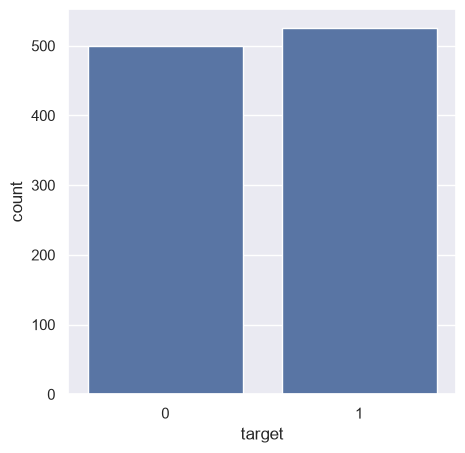

In [38]:
plt.figure(figsize=(5,5))
sns.countplot(x=df[TARGET_COL])
plt.show()

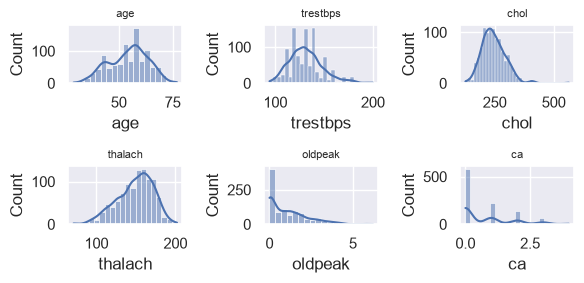

In [43]:
fig,axes=plt.subplots(2,3,figsize=(6,3))
axes=axes.flatten()
for i, col in enumerate(nums_cols):
    sns.histplot(df[col],kde=True,ax=axes[i])
    axes[i].set_title(col,fontsize=8)
    
plt.tight_layout()
plt.show()

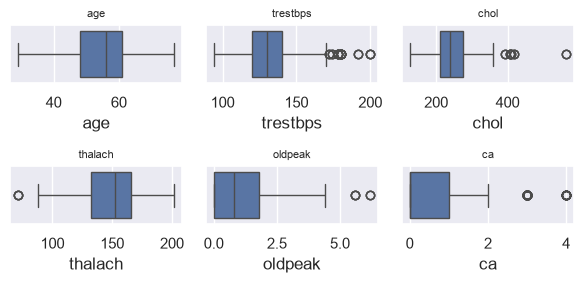

In [44]:
fig,axes=plt.subplots(2,3,figsize=(6,3))
axes=axes.flatten()
for i, col in enumerate(nums_cols):
    sns.boxplot(x=df[col],ax=axes[i])
    axes[i].set_title(col,fontsize=8)
    
plt.tight_layout()
plt.show()

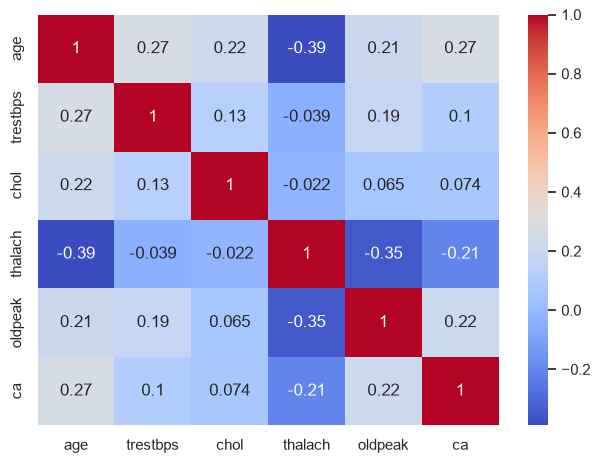

In [46]:

sns.heatmap(df[nums_cols].corr(),annot=True,cmap="coolwarm")
# axes[i].set_title(col,fontsize=8)
    
plt.tight_layout()
plt.show()

### 5 .Data Preprocessing

In [50]:
X=df.drop(columns=[TARGET_COL])
y=df[TARGET_COL]

row_signature=pd.util.hash_pandas_object(x,index=False)


In [54]:
gss=GroupShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=RANDOM_STATE
)

train_idx,test_idx=next(
    gss.split(X,y,groups=row_signature)
)

X_train,X_test=X.iloc[train_idx],X.iloc[test_idx]
y_train,y_test=y.iloc[train_idx],y.iloc[test_idx]


print("Train shape",X_train.shape)
print("Test shape",X_test.shape)


Train shape (869, 13)
Test shape (156, 13)


### 6.BaseLine Model

In [66]:
Base_pipe=Pipeline(
    steps=[
        ("scaler",StandardScaler()),
        ("model",LogisticRegression())
        
    ]
)

In [67]:
Base_pipe.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','sex','cp',...,'slope','ca','thal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


### 7.Evaluation

In [68]:
def evaluate_classifier(model,X_train,y_train,X_test,y_test,model_name):
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)
    
    #accuracy score
    train_acc=accuracy_score(y_train,y_train_pred)*100
    test_acc=accuracy_score(y_test,y_test_pred)*100
    
    #results
    print(f"{model_name}-Train Accuracy:{train_acc:.2f}%\n")
    print(f"{model_name}-Test Accuracy:{test_acc:.2f}%\n")
    
    print("-"*50)
    print("Train classification Report:")
    print(classification_report(y_train,y_train_pred))
    print("-"*50)
    print("Test classification Report:")
    print(classification_report(y_test,y_test_pred))

In [62]:
evaluate_classifier(Base_pipe,X_train,y_train,X_test,y_test,"LogisticRegression")

LogisticRegression-Train Accuracy:84.23%

LogisticRegression-Test Accuracy:83.33%

--------------------------------------------------
Train classification Report:
              precision    recall  f1-score   support

           0       0.88      0.79      0.83       430
           1       0.81      0.89      0.85       439

    accuracy                           0.84       869
   macro avg       0.85      0.84      0.84       869
weighted avg       0.85      0.84      0.84       869

--------------------------------------------------
Test classification Report:
              precision    recall  f1-score   support

           0       0.89      0.71      0.79        69
           1       0.80      0.93      0.86        87

    accuracy                           0.83       156
   macro avg       0.85      0.82      0.83       156
weighted avg       0.84      0.83      0.83       156



### 8. Model selection

In [73]:
models={
    "LogisticRegression":LogisticRegression(random_state=RANDOM_STATE),
    "svc":SVC(random_state=RANDOM_STATE),
    "Random Forest":RandomForestClassifier(random_state=RANDOM_STATE),
    "XGBoost":XGBClassifier()
    
}

In [65]:
groups=pd.util.hash_pandas_object(X_train,index=False)
k=5
cv=StratifiedGroupKFold(n_splits=k,shuffle=True,random_state=RANDOM_STATE)

In [79]:
for name,model in models.items():
    recall_scores=[]
    f1_scores=[]
    
    for tr_idx,te_idx in cv.split(X_train,y_train,groups=groups):
        X_tr,X_te=X_train.iloc[tr_idx],X_train.iloc[te_idx]
        y_tr,y_te=y_train.iloc[tr_idx],y_train.iloc[te_idx]
        
        
        pipeline=Pipeline(
            steps=[
                ("scaler",StandardScaler()),
                ("model",model)
        
              ]
        )
        
        pipeline.fit(X_tr,y_tr)
        pred=pipeline.predict(X_te)
        
        recall_scores.append(round(recall_score(y_te,pred),3))
        f1_scores.append(round(f1_score(y_te,pred),4))
        
        
    print("Model Name: ",name)
    print("Recall values",recall_scores)
    print("F1_scores:",f1_scores)
    print("\nCV recall means:" ,round(float(np.mean(recall_scores)),4))
    print("\nCV f1 means:", round(float(np.mean(f1_scores)),4))
    print("-"*50)
    
    
        

Model Name:  LogisticRegression
Recall values [0.897, 0.753, 0.931, 0.888, 0.816]
F1_scores: [0.8667, 0.7528, 0.9101, 0.8187, 0.7474]

CV recall means: 0.857

CV f1 means: 0.8191
--------------------------------------------------
Model Name:  svc
Recall values [0.793, 0.719, 0.816, 0.955, 0.724]
F1_scores: [0.7624, 0.7619, 0.8353, 0.8333, 0.6923]

CV recall means: 0.8014

CV f1 means: 0.777
--------------------------------------------------
Model Name:  Random Forest
Recall values [0.931, 0.82, 0.897, 0.921, 0.816]
F1_scores: [0.8757, 0.8066, 0.8715, 0.8677, 0.7474]

CV recall means: 0.877

CV f1 means: 0.8338
--------------------------------------------------
Model Name:  XGBoost
Recall values [0.816, 0.719, 0.897, 0.966, 0.816]
F1_scores: [0.7933, 0.7758, 0.8571, 0.8731, 0.7208]

CV recall means: 0.8428

CV f1 means: 0.804
--------------------------------------------------


### 9 .HyperParameter Tuning

In [82]:
rfc_pipe=Pipeline(
    steps=[
        ("scaler",StandardScaler()),
        ("model",RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]
)

In [99]:
params={
    "model__n_estimators":randint(400,1200),
    "model__max_depth":[3,4,5,6],
    "model__min_samples_split":randint(10,40),
    "model__min_samples_leaf":randint(4,20),
    "model__max_features":[0.25,0.35,0.5],
    "model__bootstrap":[True],
    "model__max_samples":uniform(0.6,0.35),
    "model__ccp_alpha":uniform(0.0,0.02),
}

In [100]:
random_search=RandomizedSearchCV(
    estimator=rfc_pipe,
    param_distributions=params,
    n_iter=60,
    scoring="f1_macro",
    cv=cv,
    random_state=RANDOM_STATE,
    verbose=2,
    n_jobs=-1
)

In [101]:
random_search.fit(X_train,y_train,groups=groups)


Fitting 5 folds for each of 60 candidates, totalling 300 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__bootstrap': [True], 'model__ccp_alpha': <scipy.stats....001E73163EB50>, 'model__max_depth': [3, 4, ...], 'model__max_features': [0.25, 0.35, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",60
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedGro... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a 

In [102]:
print("Hyperparameter tuning results")
print("best params:",random_search.best_params_)
print("Best_score:",random_search.best_score_)

Hyperparameter tuning results
best params: {'model__bootstrap': True, 'model__ccp_alpha': np.float64(0.00018394103233259295), 'model__max_depth': 4, 'model__max_features': 0.25, 'model__max_samples': np.float64(0.8322256191878195), 'model__min_samples_leaf': 16, 'model__min_samples_split': 27, 'model__n_estimators': 737}
Best_score: 0.852893791963765


### 10. Retrain again with optimized results

In [105]:
heart_pipeline_prediction_model=Pipeline(
    steps=[
        ('scaler',StandardScaler()),
        ("model",RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            n_estimators=random_search.best_params_['model__n_estimators'],
            max_depth=random_search.best_params_['model__max_depth'],
            min_samples_split=random_search.best_params_['model__min_samples_split'],
            min_samples_leaf=random_search.best_params_['model__min_samples_leaf'],
            max_features=random_search.best_params_['model__max_features'],
            bootstrap=random_search.best_params_['model__bootstrap'],
        ))
    ]
)

In [106]:
heart_pipeline_prediction_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['age','sex','cp',...,'slope','ca','thal']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


### 11.Model Evaluation


In [108]:
evaluate_classifier(heart_pipeline_prediction_model,X_train,y_train,X_test,y_test,RandomForestClassifier)

<class 'sklearn.ensemble._forest.RandomForestClassifier'>-Train Accuracy:89.76%

<class 'sklearn.ensemble._forest.RandomForestClassifier'>-Test Accuracy:81.41%

--------------------------------------------------
Train classification Report:
              precision    recall  f1-score   support

           0       0.94      0.85      0.89       430
           1       0.87      0.94      0.90       439

    accuracy                           0.90       869
   macro avg       0.90      0.90      0.90       869
weighted avg       0.90      0.90      0.90       869

--------------------------------------------------
Test classification Report:
              precision    recall  f1-score   support

           0       0.84      0.71      0.77        69
           1       0.80      0.90      0.84        87

    accuracy                           0.81       156
   macro avg       0.82      0.80      0.81       156
weighted avg       0.82      0.81      0.81       156



### 12. Prediction System

In [109]:
def predict_hear_disease(input_features):
    input_df=pd.DataFrame([input_features],columns=X_train.columns)
    
    prediction=heart_pipeline_prediction_model.predict(input_df)[0]
    probability=heart_pipeline_prediction_model.predict_proba(input_df)[0][1]
    print(f"Predicted Class :{prediction}")
    print(f"Heart Disease risk probability: {probability:.2f}")
    
    
    if prediction==1:
        print("Diagnosis: High risk of heart Diseases 🔴")
        
    else:
        print("Diagnosis:low risk of hear Diseases 🟢")
        
        
        
    return prediction,probability

In [110]:
y_test[y_test==1].head()

24    1
38    1
57    1
68    1
84    1
Name: target, dtype: int64

In [111]:
x_test=X_test.loc[24].tolist()
print(x_test)

[42.0, 0.0, 2.0, 120.0, 209.0, 0.0, 1.0, 173.0, 0.0, 0.0, 1.0, 0.0, 2.0]


In [112]:
predict_hear_disease(x_test)

Predicted Class :1
Heart Disease risk probability: 0.93
Diagnosis: High risk of heart Diseases 🔴


(np.int64(1), np.float64(0.9314595328641322))